# Explore cross-validation results with Augplot

Start with anonymized cross-validation results, refine the charts, inspect the generated code, and try a request outside visualization scope.

**Setup:** Follow the [README quick start](../README.md#quick-start), select the installed Python kernel, and run the cells in order with your API key.


In [1]:
import os
from getpass import getpass

os.environ["AUGPLOT_MODEL"] = "openai/gpt-6-sol"
os.environ["OPENAI_API_KEY"] = getpass("OpenAI API key: ")

import augplot as ap

## 1. Start with the results dictionary

Load scores and timing results for eight anonymized configurations, with three folds per metric.


In [2]:
data = {
    'Configuration A': {
        'fit_time': [
            10.99207282,
            2.23052597,
            2.44341564
        ],
        'score_time': [
            2.36097622,
            2.28954887,
            2.30293131
        ],
        'test_accuracy': [
            0.97229551,
            0.96963696,
            0.96963696
        ],
        'test_f1': [
            0.3,
            0.23333333,
            0.39473684
        ],
        'test_roc_auc': [
            0.93259881,
            0.96563605,
            0.93583818
        ],
        'test_pr_auc': [
            0.48858328,
            0.53131777,
            0.43261535
        ]
    },
    'Configuration B': {
        'fit_time': [
            2.46004105,
            2.32433677,
            2.49117517
        ],
        'score_time': [
            4.52269793,
            4.5832684,
            4.45985627
        ],
        'test_accuracy': [
            0.97295515,
            0.96963696,
            0.97029703
        ],
        'test_f1': [
            0.32786885,
            0.23333333,
            0.36619718
        ],
        'test_roc_auc': [
            0.93148589,
            0.96746666,
            0.93487763
        ],
        'test_pr_auc': [
            0.49539136,
            0.54551222,
            0.43102229
        ]
    },
    'Configuration C': {
        'fit_time': [
            2.54093385,
            2.47704411,
            2.68750334
        ],
        'score_time': [
            8.79027057,
            8.73184943,
            8.70324516
        ],
        'test_accuracy': [
            0.97163588,
            0.96963696,
            0.9709571
        ],
        'test_f1': [
            0.29508197,
            0.23333333,
            0.37142857
        ],
        'test_roc_auc': [
            0.93176412,
            0.96735529,
            0.93526742
        ],
        'test_pr_auc': [
            0.48784709,
            0.52116449,
            0.4343801
        ]
    },
    'Configuration D': {
        'fit_time': [
            19.86914206,
            20.26990962,
            20.23859239
        ],
        'score_time': [
            2.23791385,
            2.30841517,
            2.36348033
        ],
        'test_accuracy': [
            0.97427441,
            0.97029703,
            0.9709571
        ],
        'test_f1': [
            0.4,
            0.30769231,
            0.43589744
        ],
        'test_roc_auc': [
            0.93259881,
            0.96563605,
            0.93583818
        ],
        'test_pr_auc': [
            0.48858328,
            0.53131777,
            0.43261535
        ]
    },
    'Configuration E': {
        'fit_time': [
            2.28211403,
            2.10702777,
            2.10689068
        ],
        'score_time': [
            2.3681004,
            2.31128812,
            2.2627933
        ],
        'test_accuracy': [
            0.84894459,
            0.83960396,
            0.86270627
        ],
        'test_f1': [
            0.26837061,
            0.27893175,
            0.2972973
        ],
        'test_roc_auc': [
            0.93259881,
            0.96563605,
            0.93583818
        ],
        'test_pr_auc': [
            0.48858328,
            0.53131777,
            0.43261535
        ]
    },
    'Configuration F': {
        'fit_time': [
            68.76377082,
            127.00669312,
            68.25135517
        ],
        'score_time': [
            8.18515182,
            12.27410483,
            4.02576637
        ],
        'test_accuracy': [
            0.95778364,
            0.97029703,
            0.94653465
        ],
        'test_f1': [
            0.46666667,
            0.55445545,
            0.37209302
        ],
        'test_roc_auc': [
            0.92881488,
            0.97073809,
            0.93657599
        ],
        'test_pr_auc': [
            0.4823862,
            0.54078925,
            0.41896617
        ]
    },
    'Configuration G': {
        'fit_time': [
            68.23296738,
            68.21269846,
            68.23472333
        ],
        'score_time': [
            5.71458936,
            12.53859258,
            4.3678112
        ],
        'test_accuracy': [
            0.95778364,
            0.97029703,
            0.94653465
        ],
        'test_f1': [
            0.46666667,
            0.55445545,
            0.37209302
        ],
        'test_roc_auc': [
            0.92881488,
            0.97073809,
            0.93657599
        ],
        'test_pr_auc': [
            0.4823862,
            0.54078925,
            0.41896617
        ]
    },
    'Configuration H': {
        'fit_time': [
            68.36466432,
            68.23779011,
            68.26517701
        ],
        'score_time': [
            6.51451588,
            10.39382553,
            30.03136373
        ],
        'test_accuracy': [
            0.97163588,
            0.97029703,
            0.96963696
        ],
        'test_f1': [
            0.31746032,
            0.21052632,
            0.34285714
        ],
        'test_roc_auc': [
            0.93433774,
            0.96615809,
            0.93663168
        ],
        'test_pr_auc': [
            0.47888534,
            0.53860743,
            0.41860344
        ]
    }
}

In [3]:
print(f"{len(data)} configurations")
print("Metrics:", ", ".join(next(iter(data.values()))))
print("Folds per metric:", len(data["Configuration A"]["test_f1"]))

8 configurations
Metrics: fit_time, score_time, test_accuracy, test_f1, test_roc_auc, test_pr_auc
Folds per metric: 3


## 2. Ask for an initial view

Let Augplot choose an initial view


Augplot: plotting... attempt 1/2
Augplot: still waiting for the model (attempt 1/2)...
Augplot: checking generated plotting code...


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


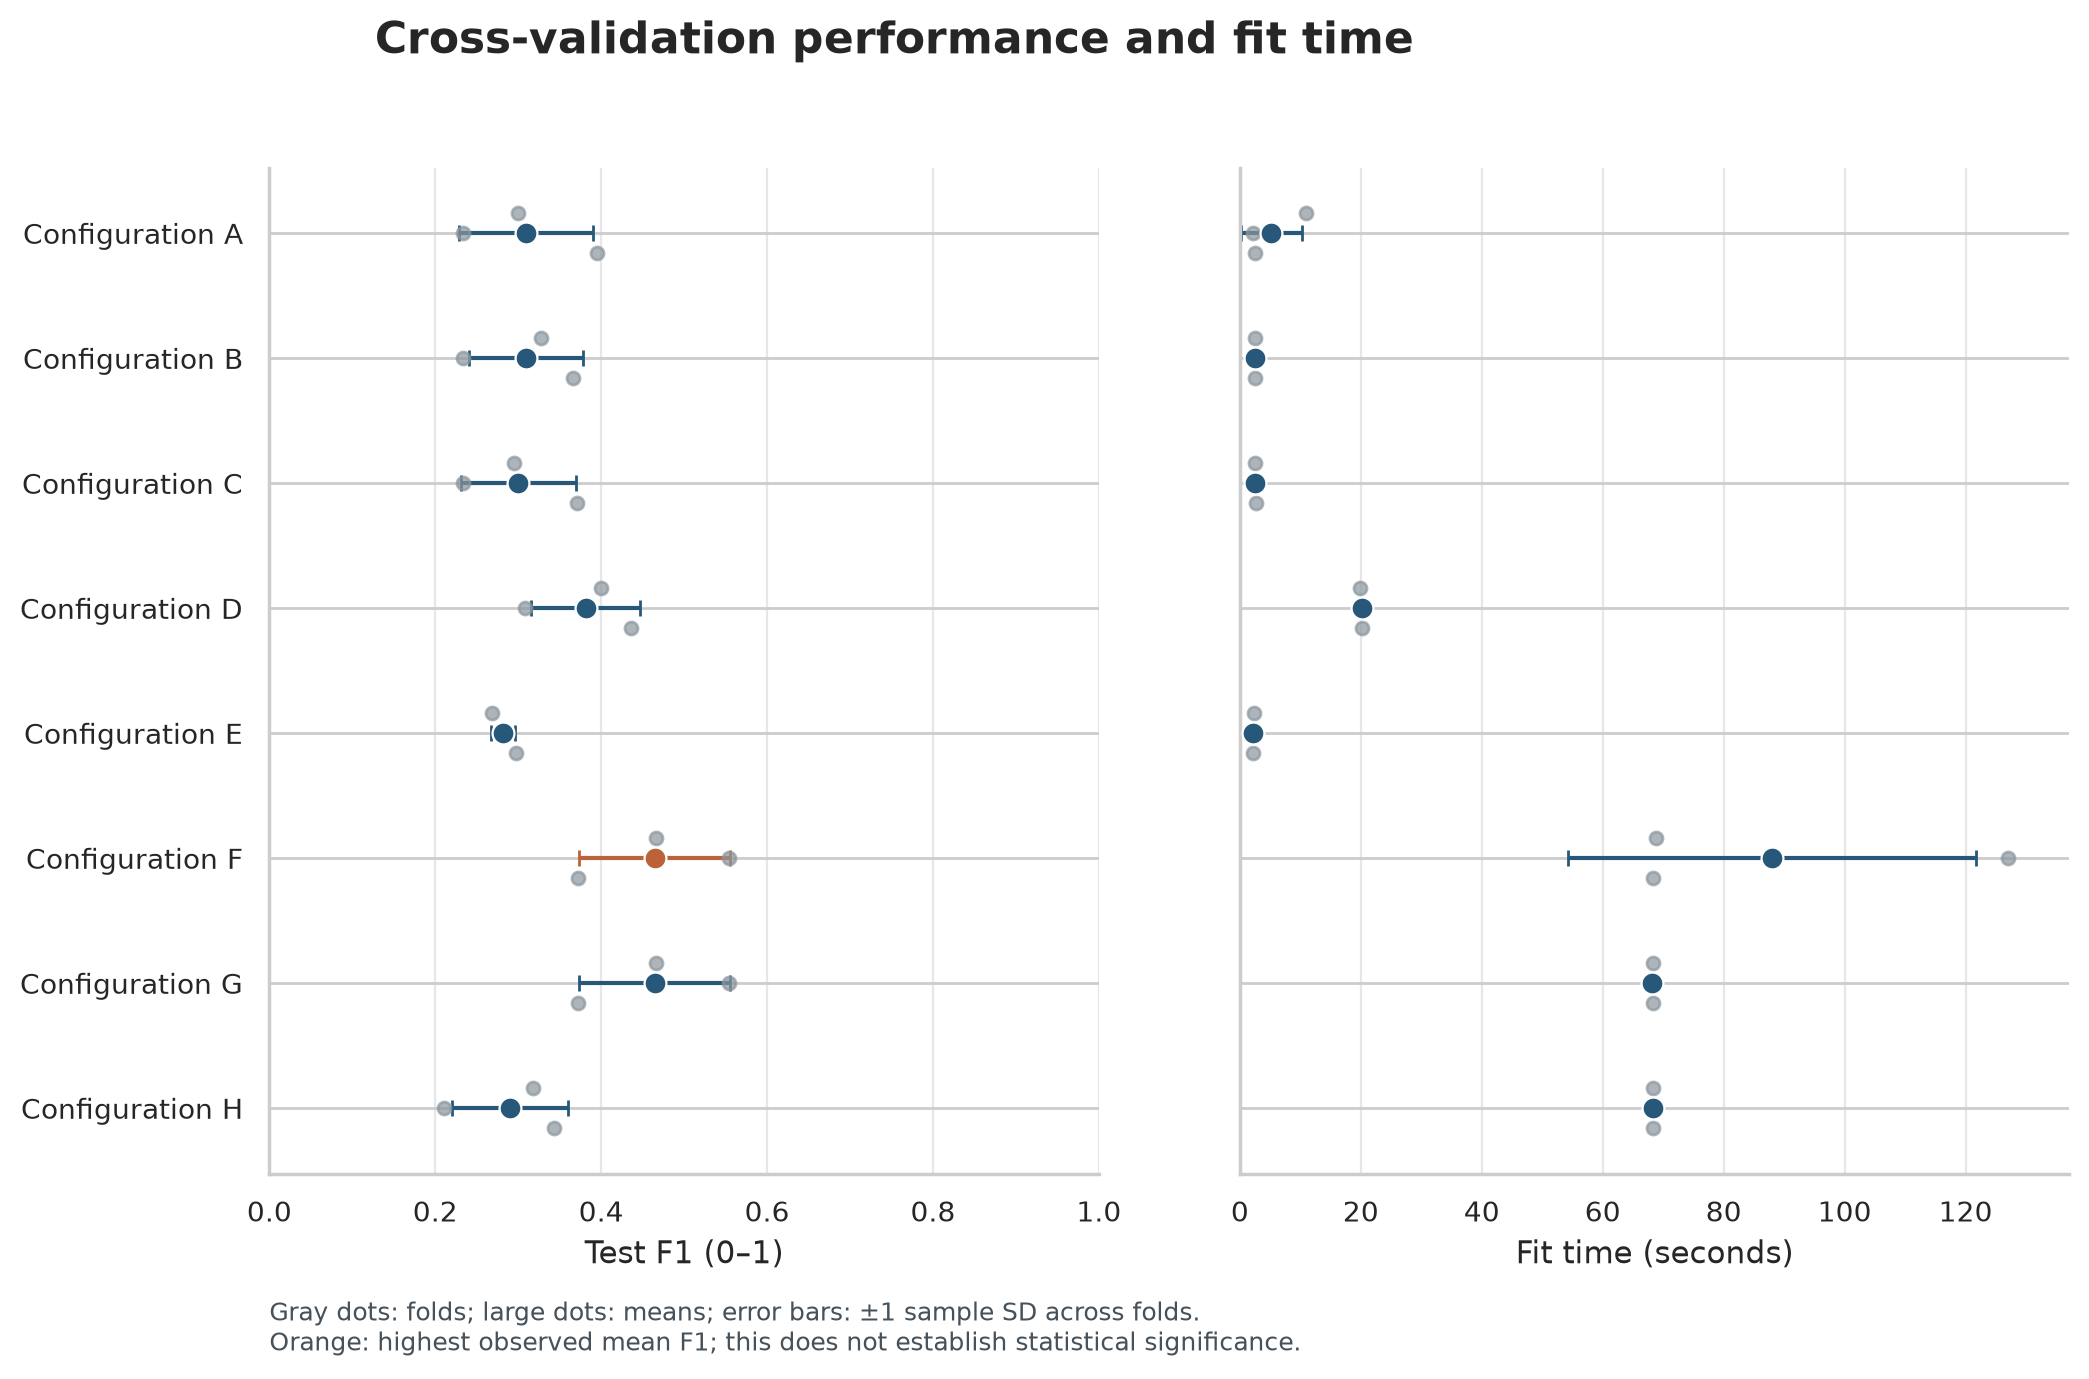

In [4]:
vis = ap.plot(data)

## 3. Focus on F1 in one chart

Refine the view to a horizontal bar chart of mean test F1 for each configuration.


Augplot: plotting... attempt 1/2
Augplot: checking generated plotting code...


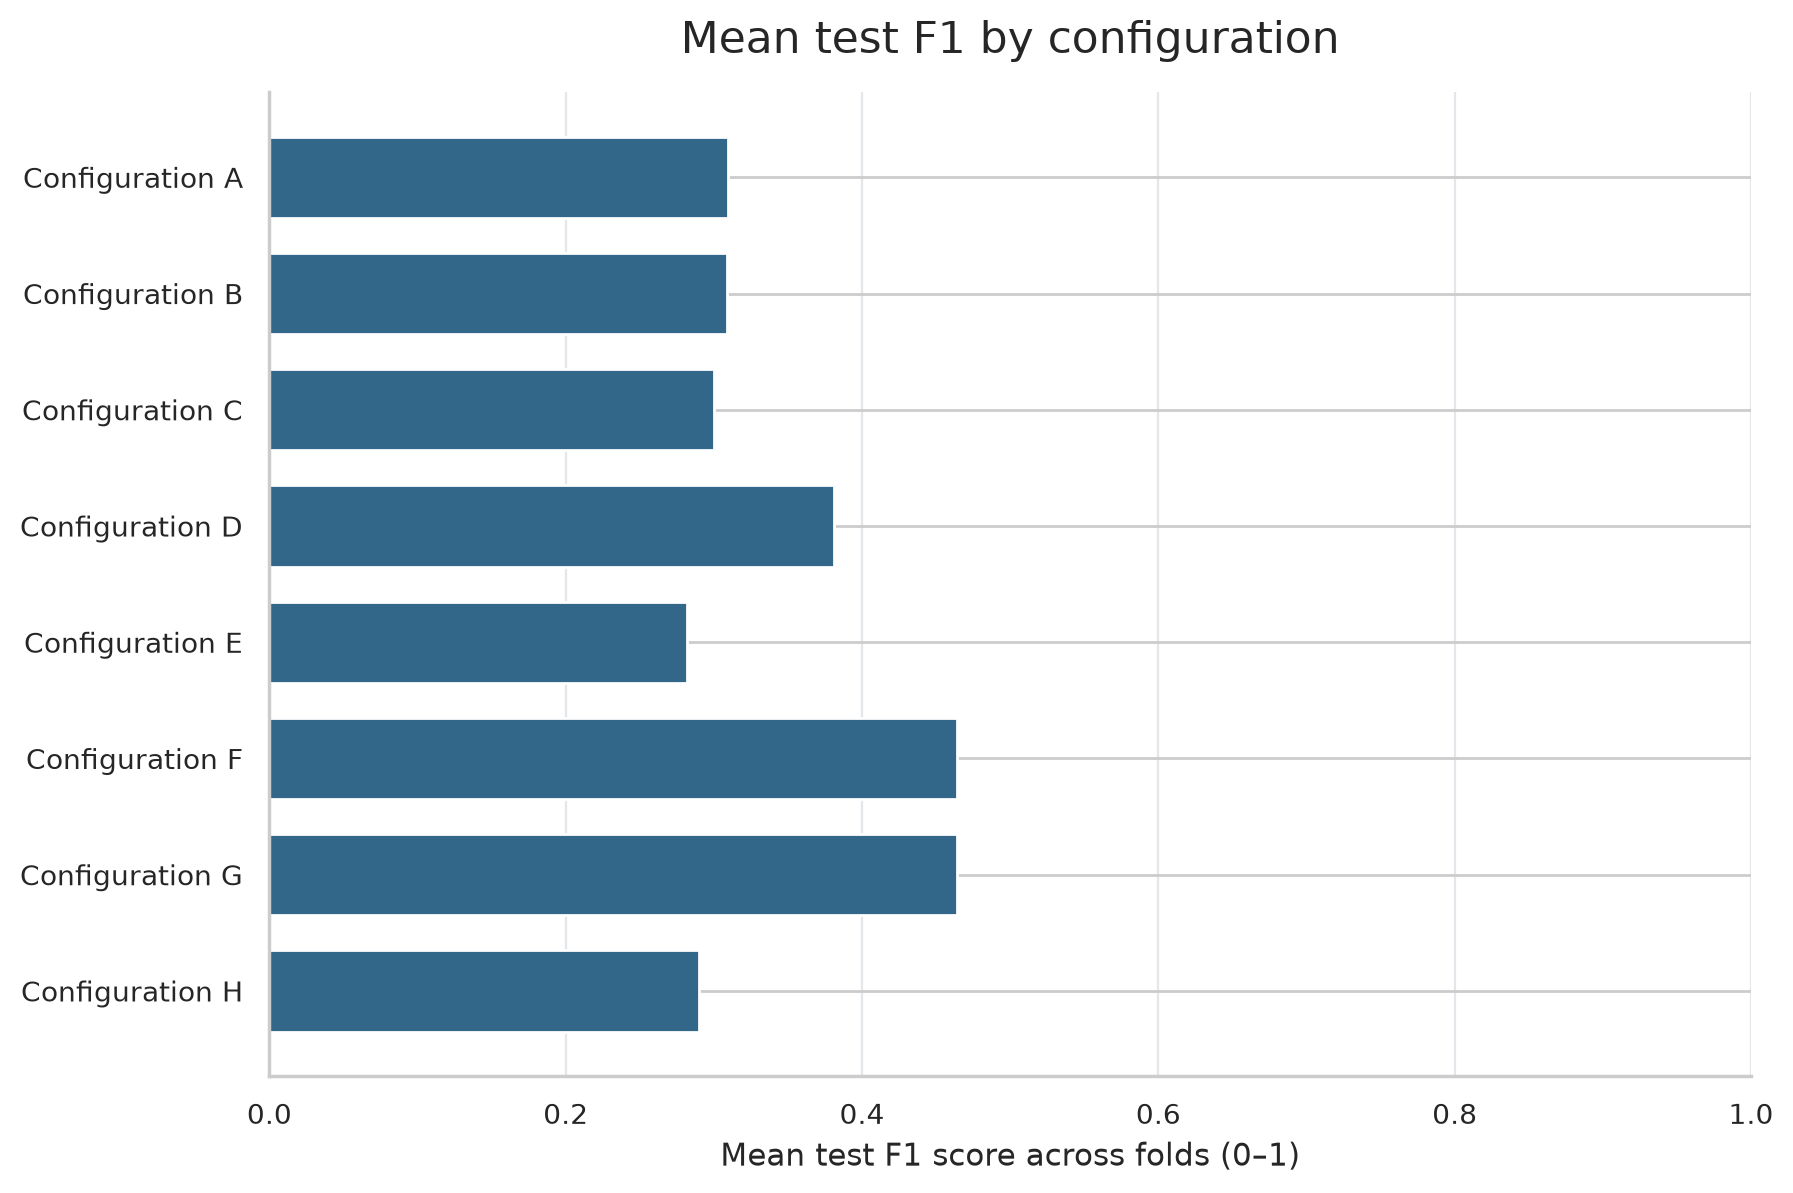

Augplot(backend='auto', state='fitted')

In [5]:
vis.refine(
    "Show the mean test F1 score for every configuration in one horizontal bar chart. "
)

## 4. Add ROC AUC as a second metric

Add mean test ROC AUC beside F1 for each configuration.


Augplot: plotting... attempt 1/2
Augplot: still waiting for the model (attempt 1/2)...
Augplot: checking generated plotting code...


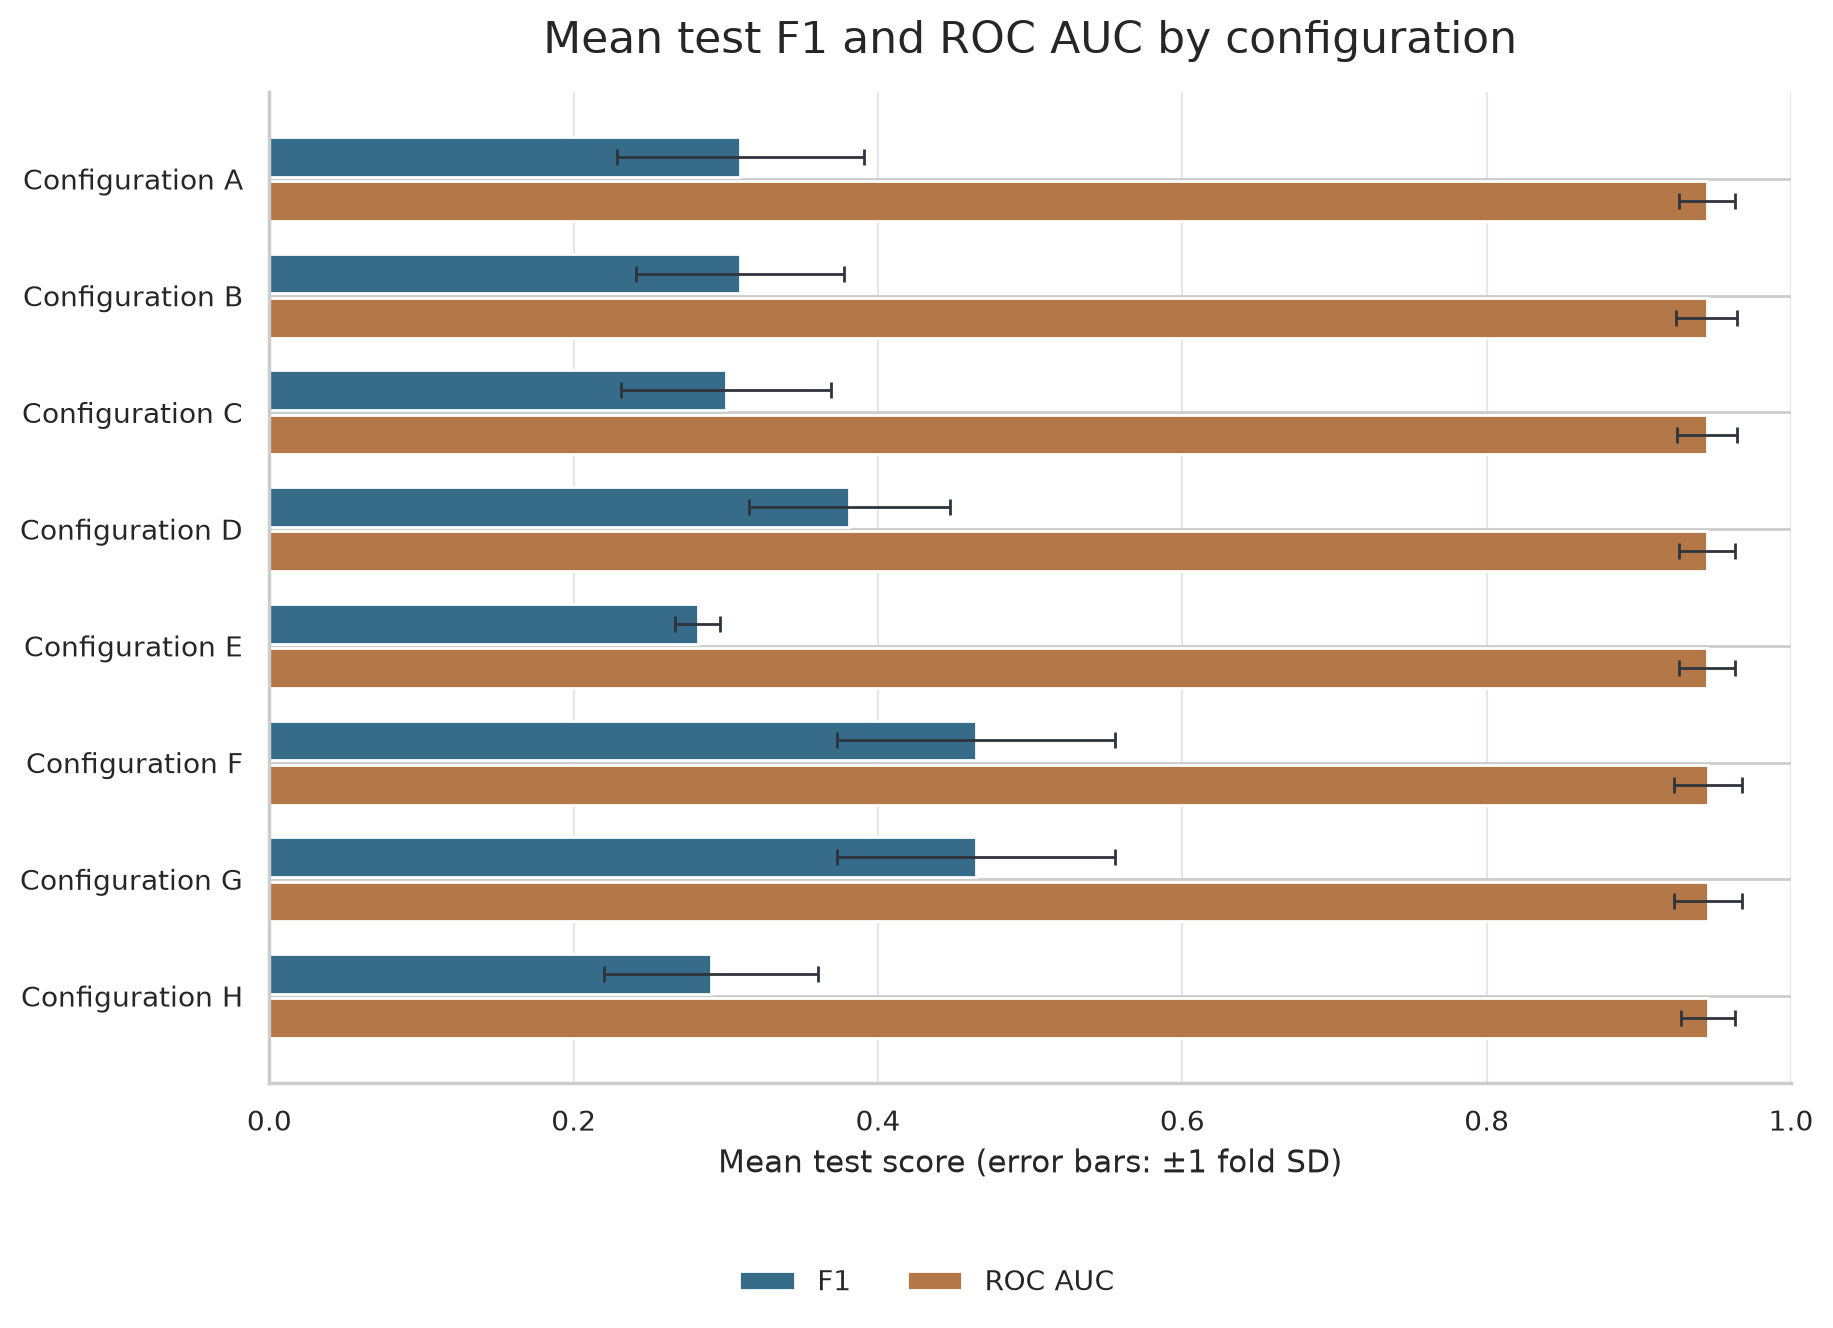

Augplot(backend='auto', state='fitted')

In [6]:
vis.refine(
    "Add a second bar for each configuration using test_roc_auc (ROC AUC). "
    "Keep F1 and ROC AUC side by side."
)

## 5. Change the orientation and highlight the F1 leaders

Switch to vertical bars and highlight both configurations tied for the highest observed mean F1.


Augplot: plotting... attempt 1/2
Augplot: still waiting for the model (attempt 1/2)...
Augplot: checking generated plotting code...


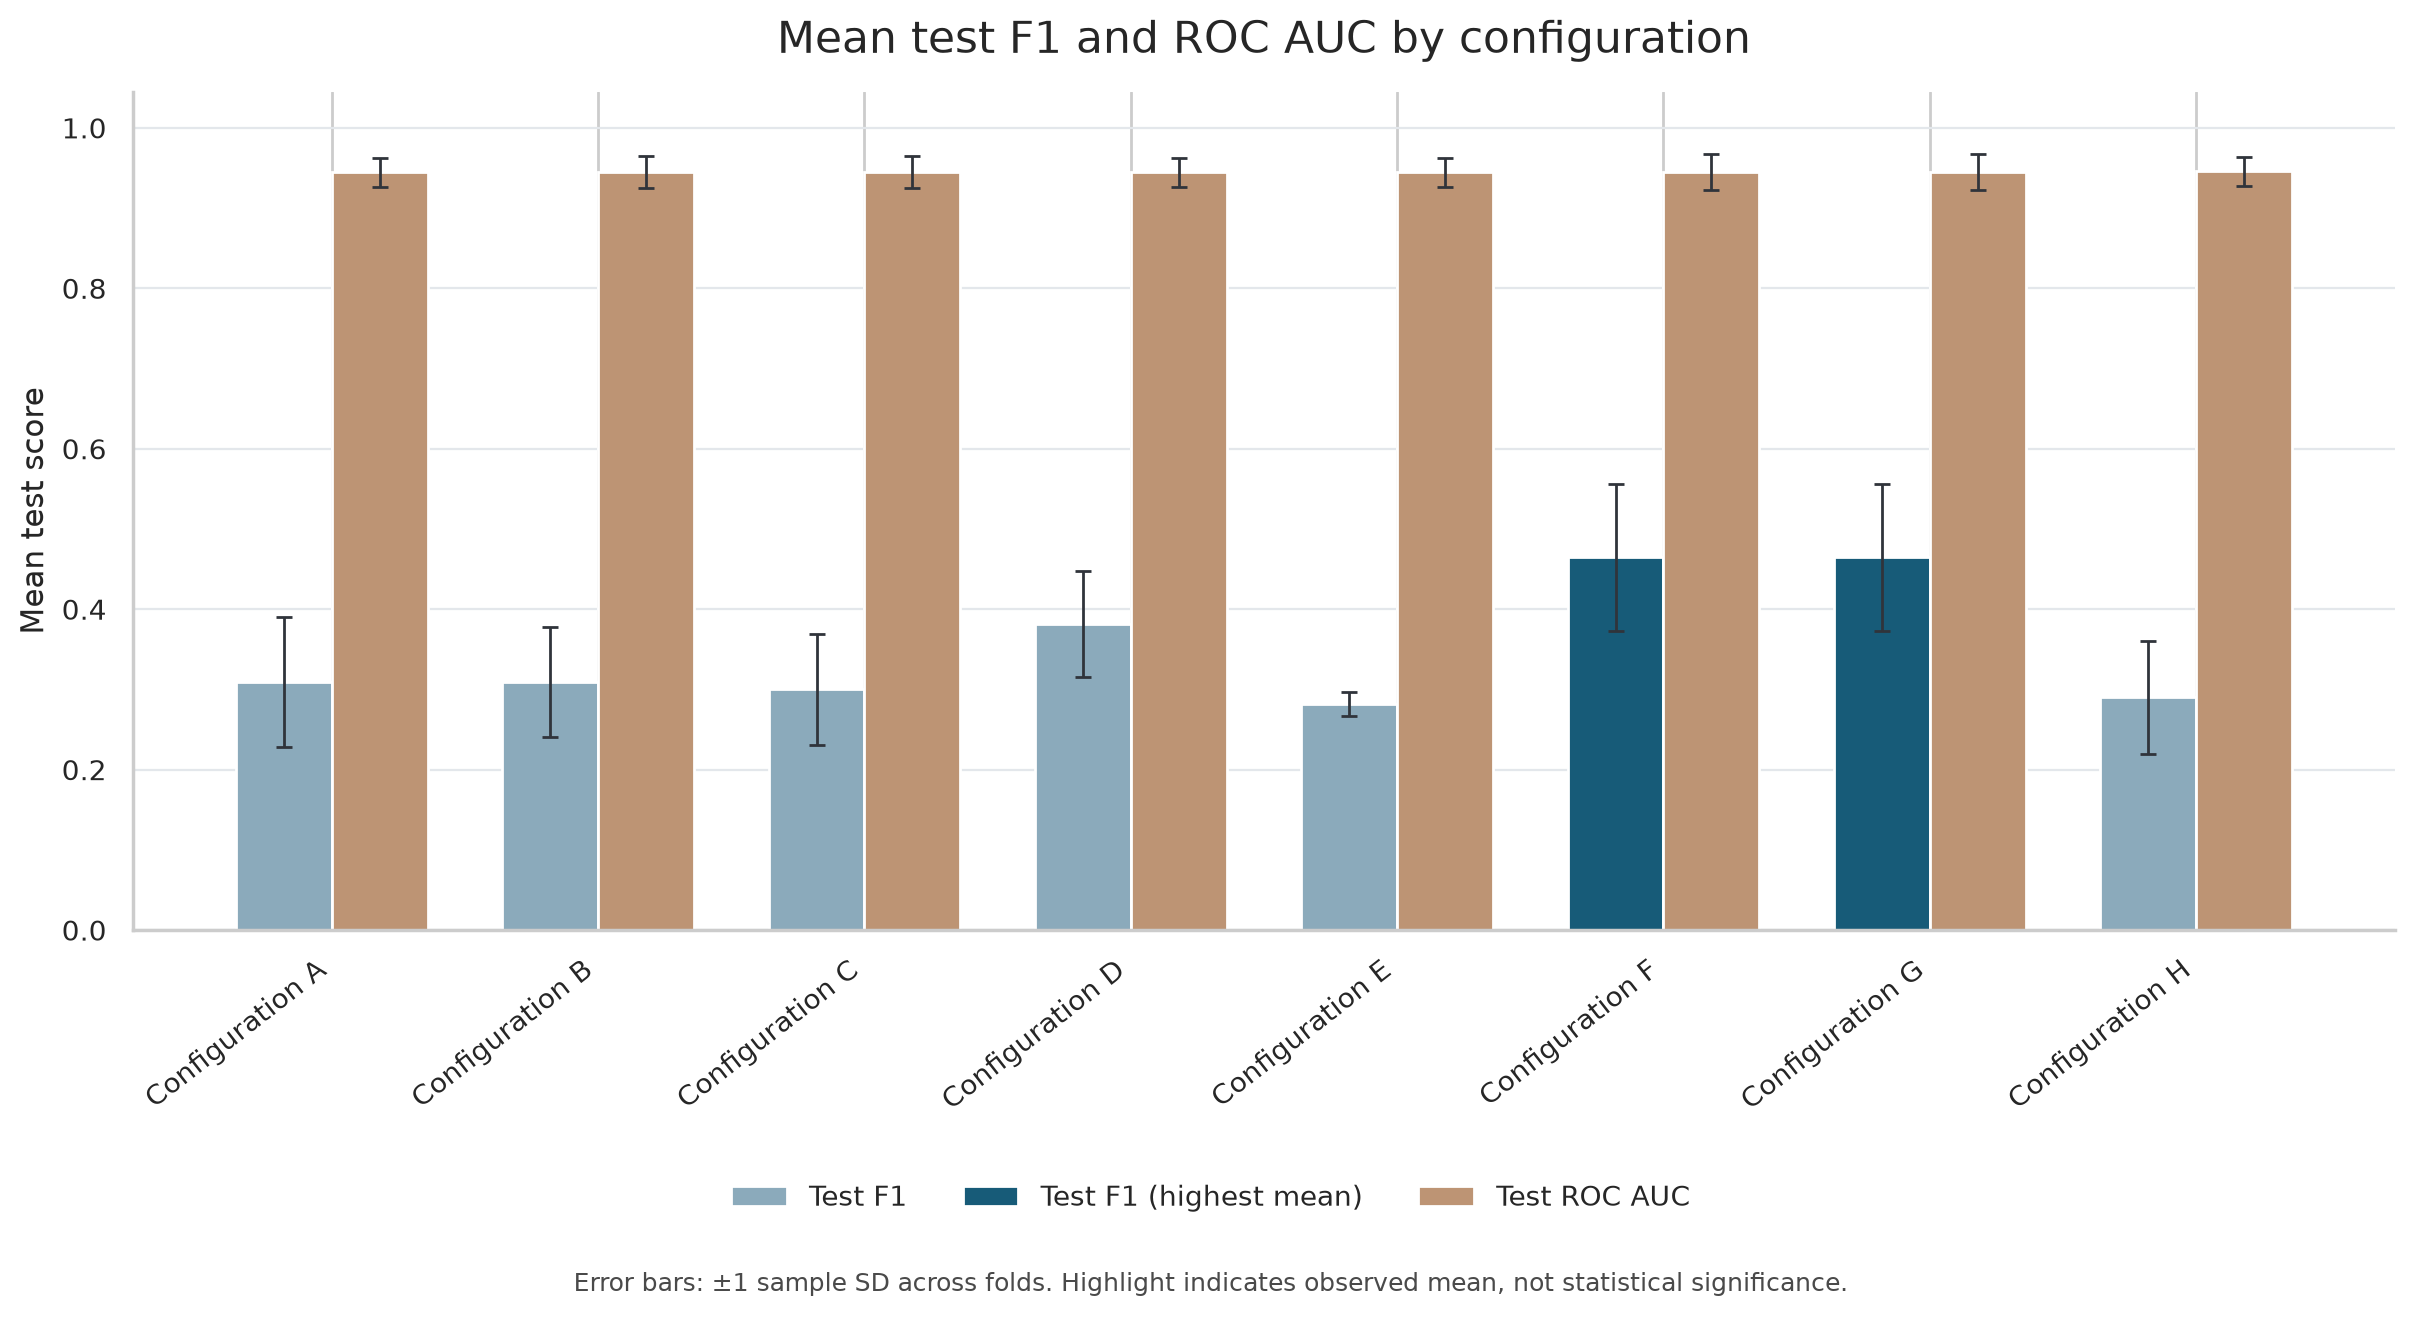

Augplot(backend='auto', state='fitted')

In [7]:
vis.refine(
    "Make the grouped bars vertical and highlight every configuration tied for the "
    "highest observed mean test F1."
)

## 6. Add exact mean labels and inspect the function

Label each mean to two decimal places, then inspect the generated plotting function in `vis.code`.


Augplot: plotting... attempt 1/2
Augplot: checking generated plotting code...


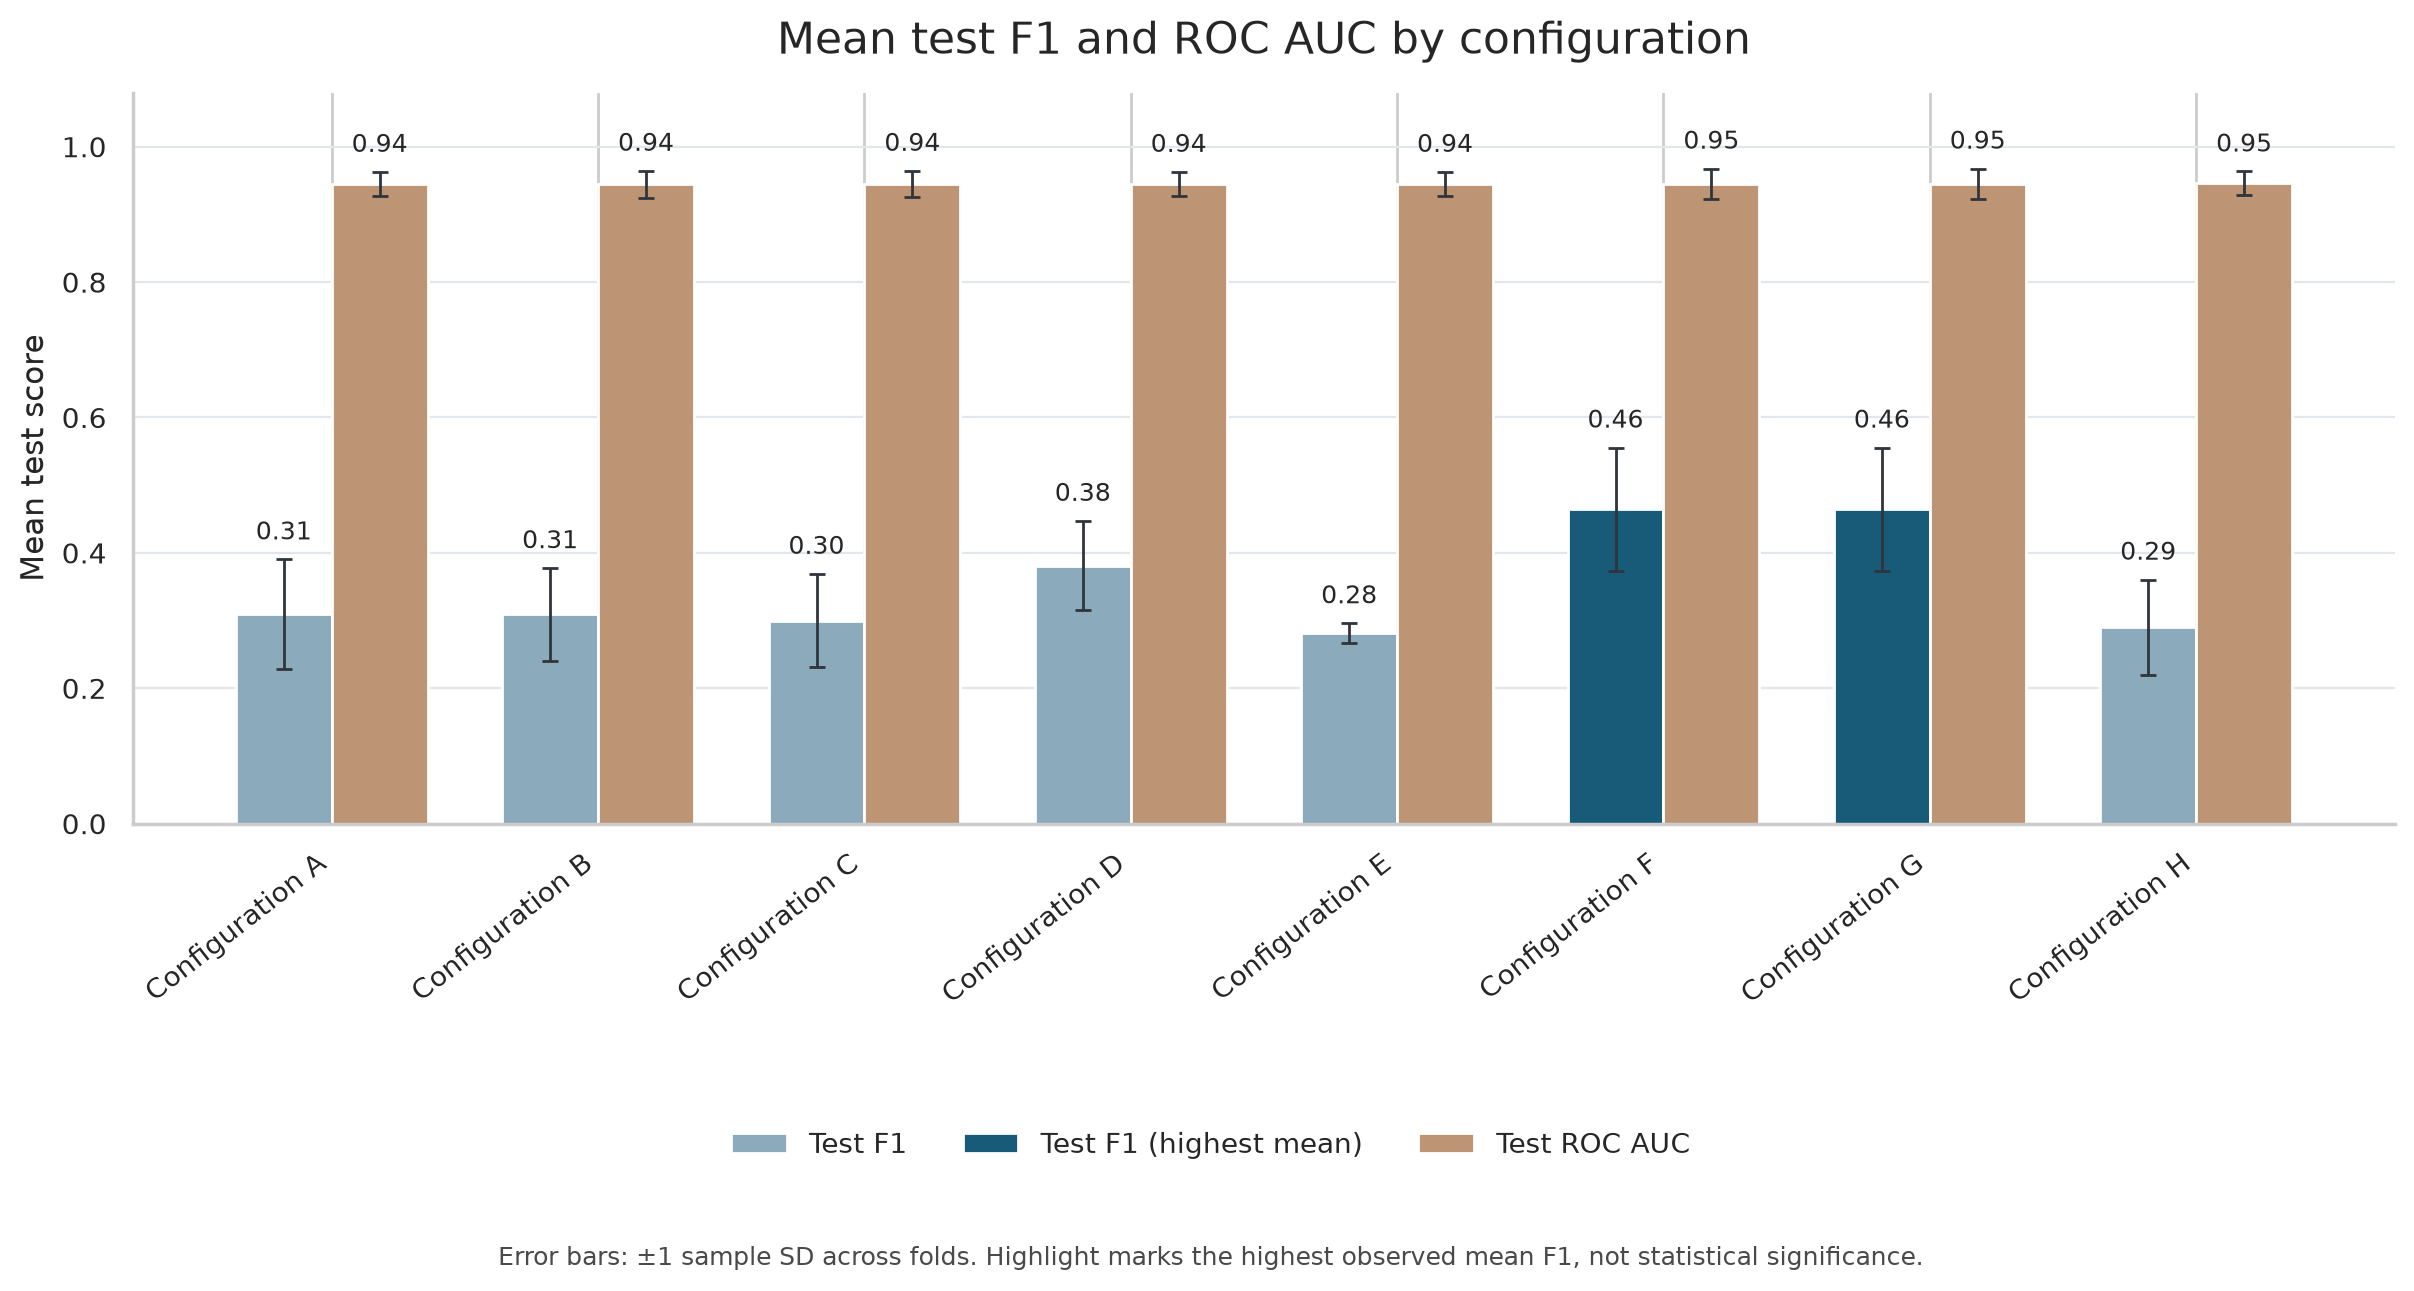

Augplot(backend='auto', state='fitted')

In [8]:
vis.refine(
    "Label each F1 and ROC AUC bar with its mean score to two decimal places. "
)

In [9]:
from IPython.display import Code

Code(vis.code, language="python")

def plot_data(data, *, title=None, figsize=None):
    import numpy as np
    import matplotlib.pyplot as plt

    results = data.copy()
    names = list(results)
    f1_folds = [np.asarray(results[name]['test_f1'], dtype=float) for name in names]
    auc_folds = [np.asarray(results[name]['test_roc_auc'], dtype=float) for name in names]
    f1_means = np.asarray([np.mean(values) for values in f1_folds])
    auc_means = np.asarray([np.mean(values) for values in auc_folds])
    f1_sd = np.asarray([np.std(values, ddof=1) if len(values) > 1 else 0 for values in f1_folds])
    auc_sd = np.asarray([np.std(values, ddof=1) if len(values) > 1 else 0 for values in auc_folds])
    highest = np.isclose(f1_means, np.max(f1_means), rtol=1e-12, atol=1e-12)

    if figsize is None:
        figsize = (max(10, min(17, 1.15 * len(names) + 3)), 6.7)
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(names))
    width = 0.36
    error_style = {'ecolor': '#30343b', 'capsize': 3, 'elinewidth': 1}

    if np.any(~highest):
        ax.bar(x[~highest] - width / 2, f1_means[~highest], width,
               yerr=f1_sd[~highest], color='#8baabb', error_kw=error_style,
               label='Test F1')
    ax.bar(x[highest] - width / 2, f1_means[highest], width,
           yerr=f1_sd[highest], color='#175b78', error_kw=error_style,
           label='Test F1 (highest mean)')
    ax.bar(x + width / 2, auc_means, width, yerr=auc_sd,
           color='#bd9474', error_kw=error_style, label='Test ROC AUC')

    for i in range(len(names)):
        ax.annotate(f'{f1_means[i]:.2f}', (x[i] - width / 2, f1_means[i] + f1_sd[i]),
                    xytext=(0, 5), textcoords='offset points', ha='center',
                    va='bottom', fontsize=9)
        ax.annotate(f'{auc_means[i]:.2f}', (x[i] + width / 2, auc_means[i] + auc_sd[i]),
                    xytext=(0, 5), textcoords='offset points', ha='center',
                    va='bottom', fontsize=9)

    ax.set_xticks(x, labels=names, rotation=38, ha='right')
    ax.set_ylabel('Mean test score', fontsize=11)
    ax.set_ylim(0, max(1.08, np.max(f1_means + f1_sd) + 0.10,
                       np.max(auc_means + auc_sd) + 0.10))
    ax.set_title(title if title is not None else 'Mean test F1 and ROC AUC by configuration',
                 fontsize=16, pad=14)
    ax.set_axisbelow(True)
    ax.grid(axis='y', color='#e3e7eb', linewidth=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=10)

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.105),
               ncol=len(labels), frameon=False, fontsize=10)
    fig.text(0.5, 0.045,
             'Error bars: ±1 sample SD across folds. Highlight marks the highest observed mean F1, not statistical significance.',
             ha='center', fontsize=9, color='#4a4a4a')
    fig.tight_layout(rect=(0, 0.22, 1, 1))
    return fig

## 7. A request outside visualization scope

Try an unrelated recipe request to see Augplot raise `ScopeError`.


In [10]:
try:
    vis.refine("Show me a recipe for apple pie.")
except ap.ScopeError as exc:
    print(f"Expected ScopeError: {exc}")

Augplot: plotting... attempt 1/2
Augplot: checking generated plotting code...
Expected ScopeError: I can create visualizations from the supplied data, but a recipe is outside this scope. Please request a chart instead.


**Next:** Try another refinement, or see the [quickstart](quickstart.ipynb) for history and export.
